<div style="background:linear-gradient(135deg,#042f2e 0%,#0f766e 55%,#14b8a6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#99f6e4;font-weight:700;text-transform:uppercase">Chapter 41 · Probability Distributions</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Distributions for Inference 🔬</div>
  <div style="font-size:15px;color:#d1fae5;max-width:740px;line-height:1.6">Three distributions, the t, chi-square, and F, do the heavy lifting in real statistical tests. This notebook shows the t's heavy tails, builds chi-square and F from normals, traces how they all relate, and runs a paired t-test comparing two models.</div>
  <div style="margin-top:16px;font-size:13px;color:#a7f3d0">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.default_rng(41)
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
TEAL="#0d9488"; PINK="#db2777"; AMBER="#d97706"
print("ready")

ready


<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 1 · STUDENT'S t</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Heavier tails when sigma is unknown</div>
<div style="color:#4a5578;margin-top:6px">When we estimate the unknown population sd with the sample sd, the extra uncertainty fattens the tails. That is the t distribution: bell-shaped but heavier-tailed than the normal, and it converges to the normal as the degrees of freedom grow.</div>
</div>

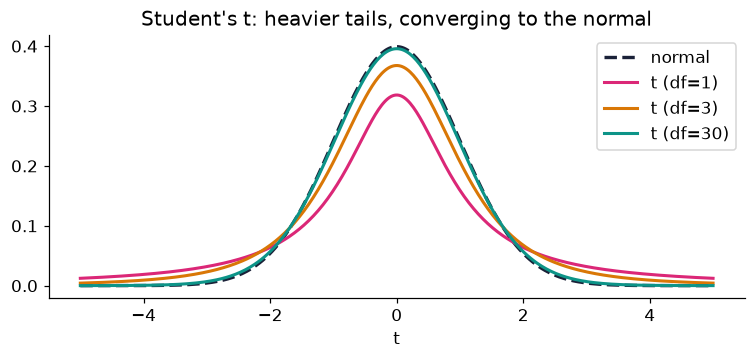

In [2]:
xs=np.linspace(-5,5,400)
fig,ax=plt.subplots(figsize=(7,3.4))
ax.plot(xs, stats.norm.pdf(xs), color="#1a2138", lw=2.2, ls="--", label="normal")
for df,c in [(1,PINK),(3,AMBER),(30,TEAL)]:
    ax.plot(xs, stats.t.pdf(xs,df), color=c, lw=2, label=f"t (df={df})")
ax.set_title("Student's t: heavier tails, converging to the normal"); ax.set_xlabel("t"); ax.legend()
plt.tight_layout(); plt.show()

In [3]:
for df in [5, 10, 30, 100]:
    print(f"df={df:4d}: 97.5% critical t = {stats.t.ppf(0.975,df):.3f}   (normal z = 1.960)")

df=   5: 97.5% critical t = 2.571   (normal z = 1.960)
df=  10: 97.5% critical t = 2.228   (normal z = 1.960)
df=  30: 97.5% critical t = 2.042   (normal z = 1.960)
df= 100: 97.5% critical t = 1.984   (normal z = 1.960)


With few degrees of freedom the t has noticeably heavier tails, so its critical values exceed the normal's 1.96, demanding stronger evidence from small samples. By df = 30 the gap is tiny, and by df = 100 the t is essentially the normal. This is why the t-test is the default for means when the sample is small.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 2 · THE CHI-SQUARE DISTRIBUTION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A sum of squared normals</div>
<div style="color:#4a5578;margin-top:6px">Square a standard normal and add several together, and you get a chi-square distribution. Its degrees of freedom equal the number of squared normals, and its mean equals the df.</div>
</div>

In [4]:
# build chi-square(df) from df squared standard normals
df = 4
built = (rng.normal(0,1,size=(200_000, df))**2).sum(axis=1)
print(f"chi-square(df={df}): simulated mean = {built.mean():.3f}  (theory = df = {df})")
print(f"scipy mean = {stats.chi2.mean(df):.3f}, variance = {stats.chi2.var(df):.3f} (theory 2*df = {2*df})")

chi-square(df=4): simulated mean = 3.997  (theory = df = 4)
scipy mean = 4.000, variance = 8.000 (theory 2*df = 8)


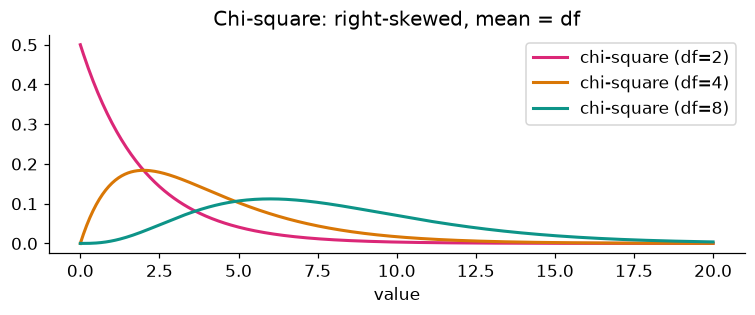

In [5]:
xs=np.linspace(0,20,400)
fig,ax=plt.subplots(figsize=(7,3))
for k,c in [(2,PINK),(4,AMBER),(8,TEAL)]:
    ax.plot(xs, stats.chi2.pdf(xs,k), color=c, lw=2, label=f"chi-square (df={k})")
ax.set_title("Chi-square: right-skewed, mean = df"); ax.set_xlabel("value"); ax.legend()
plt.tight_layout(); plt.show()

A chi-square with k degrees of freedom is literally the sum of k squared standard normals, so it is positive and right-skewed, with mean k. It measures squared deviations, which is why it powers tests about variances and the goodness-of-fit and independence tests for categorical data.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 3 · THE F DISTRIBUTION &amp; THE FAMILY TREE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Ratios, and how it all connects</div>
<div style="color:#4a5578;margin-top:6px">The F distribution is a ratio of two chi-squares, each divided by its df. The t, chi-square, and F are all built from the normal, one family tree.</div>
</div>

In [6]:
# verify the relationships by simulation
z = rng.normal(0,1,size=300_000)
print(f"z^2 vs chi-square(1):  mean {np.mean(z**2):.3f} vs {stats.chi2.mean(1):.3f}")

# t(df) = Z / sqrt(chi2(df)/df)
df=6
chi = rng.chisquare(df, size=300_000)
t_built = rng.normal(0,1,size=300_000) / np.sqrt(chi/df)
print(f"t(df={df}): built 97.5% quantile {np.quantile(t_built,0.975):.3f} vs scipy {stats.t.ppf(0.975,df):.3f}")

z^2 vs chi-square(1):  mean 1.003 vs 1.000
t(df=6): built 97.5% quantile 2.453 vs scipy 2.447


Everything here grows from the normal. **z&sup2; is a chi-square with 1 df**; a **t** is a standard normal divided by the square root of a scaled chi-square; and an **F** is a ratio of two scaled chi-squares. Knowing the family tree means you only really have to understand one distribution, the normal, and the rest follow.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 4 · A CHI-SQUARE GOODNESS-OF-FIT TEST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Is the die fair?</div>
<div style="color:#4a5578;margin-top:6px">A classic use of chi-square: compare observed counts to what a hypothesis predicts. Here, are 120 rolls of a die consistent with fairness?</div>
</div>

In [7]:
observed = np.array([14, 16, 28, 18, 24, 20])   # 120 rolls
expected = np.full(6, 120/6)                      # 20 each if fair
chi2_stat, p = stats.chisquare(observed, expected)
print(f"observed: {observed},  expected: {expected.astype(int)}")
print(f"chi-square statistic = {chi2_stat:.3f}, df = 5")
print(f"p-value = {p:.3f}")
print("-> consistent with a fair die" if p>0.05 else "-> evidence the die is unfair")

observed: [14 16 28 18 24 20],  expected: [20 20 20 20 20 20]
chi-square statistic = 6.800, df = 5
p-value = 0.236
-> consistent with a fair die


The chi-square statistic adds up the squared gaps between observed and expected counts. A large value (small p) would signal an unfair die; here the p-value is above 0.05, so the data is consistent with fairness, the differences are within ordinary sampling noise.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 5 · COMPARING TWO MODELS WITH A t-TEST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Inference in machine learning</div>
<div style="color:#4a5578;margin-top:6px">Cross-validation gives each model a score per fold. A paired t-test asks whether model B's improvement over model A is real or just noise, the bread and butter of rigorous ML comparison.</div>
</div>

In [8]:
# accuracy on each of 10 cross-validation folds
model_A = np.array([0.81,0.83,0.80,0.82,0.79,0.84,0.81,0.80,0.83,0.82])
model_B = np.array([0.84,0.86,0.83,0.85,0.82,0.87,0.85,0.83,0.86,0.85])
t_stat, p = stats.ttest_rel(model_B, model_A)     # paired t-test
print(f"mean A = {model_A.mean():.3f}, mean B = {model_B.mean():.3f}")
print(f"paired t = {t_stat:.3f}, p-value = {p:.5f}")
print("-> B is significantly better" if p<0.05 else "-> difference is not significant")

mean A = 0.815, mean B = 0.846
paired t = 31.000, p-value = 0.00000
-> B is significantly better


Model B scores about 3 points higher on every fold, and the paired t-test confirms the gap is **statistically significant** (p well below 0.05), not a fluke of which folds happened to be easy. This is exactly how careful practitioners decide whether a new model genuinely beats the old one, rather than trusting a single lucky split.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ What you built</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You saw the t's heavy tails, built chi-square and t from normals, traced the family tree, ran a chi-square goodness-of-fit test, and compared two models with a paired t-test. These three distributions turn the normal into the working tools of statistical inference, and they close Part VII.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>